In [1]:
from google.colab import drive
drive.mount('/content/drive')
print('Google Drive mounted ✅')

Mounted at /content/drive
Google Drive mounted ✅


In [2]:
!pip install segmentation-models-pytorch --quiet

import segmentation_models_pytorch as smp
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

model = smp.Unet(
    encoder_name="resnet34",
    encoder_weights="imagenet",
    in_channels=3,
    classes=1,
)

model.to(device)
print("Pre-trained UNet with ResNet34 backbone loaded.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 5.4 MB/s eta 0:00:00
Using device: cuda


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/87.3M [00:00<?, ?B/s]

Pre-trained UNet with ResNet34 backbone loaded.


In [3]:

!wget http://images.cocodataset.org/zips/val2017.zip

!wget http://images.cocodataset.org/annotations/annotations_trainval2017.zip

!unzip -q val2017.zip -d /content/drive/MyDrive/VISION_AI/
!unzip -q annotations_trainval2017.zip -d /content/drive/MyDrive/VISION_AI/

print("✅ COCO val2017 and annotations downloaded and extracted")

--2025-09-25 13:30:30--  http://images.cocodataset.org/zips/val2017.zip
Resolving images.cocodataset.org (images.cocodataset.org)... 16.15.176.27, 52.216.140.140, 16.15.194.224, ...
Connecting to images.cocodataset.org (images.cocodataset.org)|16.15.176.27|:80... connected.
HTTP request sent, awaiting response... 200 OK
Length: 815585330 (778M) [application/zip]
Saving to: ‘val2017.zip’

val2017.zip         100%[===================>] 777.80M  36.8MB/s    in 17s     

2025-09-25 13:30:47 (46.5 MB/s) - ‘val2017.zip’ saved [815585330/815585330]

--2025-09-25 13:30:47--  http://images.cocodataset.org/annotations/annotations_trainval2017.zip
Resolving images.cocodataset.org (images.cocodataset.org)... 16.15.189.130, 16.15.196.130, 3.5.29.173, ...
Connecting to images.cocodataset.org (images.cocodataset.org)|16.15.189.130|:80... connected.
HTTP request sent, awaiting response... 200 OK
Length: 252907541 (241M) [application/zip]
Saving to: ‘annotations_trainval2017.zip’

annotations_trainva 1

In [4]:
import os
import numpy as np
from PIL import Image
from pycocotools.coco import COCO

ann_path = "/content/drive/MyDrive/VISION_AI/annotations/instances_val2017.json"
img_dir = "/content/drive/MyDrive/VISION_AI/val2017"
out_mask_dir = "/content/drive/MyDrive/VISION_AI/Binary_Mask"
os.makedirs(out_mask_dir, exist_ok=True)

# Load COCO annotations
coco = COCO(ann_path)

# Get first 500 image IDs only
img_ids = coco.getImgIds()[:500]

for img_id in img_ids:
    img_info = coco.loadImgs(img_id)[0]  # single image info
    anns = coco.loadAnns(coco.getAnnIds(imgIds=img_id))

    # Initialize empty mask
    mask = np.zeros((img_info["height"], img_info["width"]), dtype=np.uint8)

    for ann in anns:
        if 'segmentation' in ann and ann['segmentation']:
            mask = np.maximum(mask, coco.annToMask(ann) * 255)

    # Save mask as PNG
    mask_img = Image.fromarray(mask)
    mask_name = img_info['file_name'].replace(".jpg", ".png")
    mask_img.save(os.path.join(out_mask_dir, mask_name))

print("✅ Binary masks generated for 500 images and saved in:", out_mask_dir)


loading annotations into memory...
Done (t=1.61s)
creating index...
index created!
✅ Binary masks generated for 500 images and saved in: /content/drive/MyDrive/VISION_AI/Binary_Mask


In [5]:
import torch
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms
from PIL import Image
import os
from tqdm import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
img_dir = "/content/drive/MyDrive/VISION_AI/val2017"
out_mask_dir = "/content/drive/MyDrive/VISION_AI/Binary_Mask"


class SegmentationDataset(Dataset):
    def __init__(self, images_dir, masks_dir, transform_img=None, transform_mask=None):
        self.images_dir = images_dir
        self.masks_dir = masks_dir
        self.image_files = sorted([f for f in os.listdir(images_dir) if f.endswith(".jpg")])
        self.mask_files = set([f for f in os.listdir(masks_dir) if f.endswith(".png")])
        self.valid_pairs = [(img, img.replace(".jpg", ".png")) for img in self.image_files
                            if img.replace(".jpg", ".png") in self.mask_files]
        self.transform_img = transform_img
        self.transform_mask = transform_mask
        print(f"Dataset initialized with {len(self.valid_pairs)} image-mask pairs.")

    def __len__(self):
        return len(self.valid_pairs)

    def __getitem__(self, idx):
        img_name, mask_name = self.valid_pairs[idx]
        img_path = os.path.join(self.images_dir, img_name)
        mask_path = os.path.join(self.masks_dir, mask_name)
        image = Image.open(img_path).convert("RGB")
        mask = Image.open(mask_path).convert("L")
        if self.transform_img:
            image = self.transform_img(image)
        if self.transform_mask:
            mask = self.transform_mask(mask)
            mask = (mask > 0).float()
        return image, mask

transform_img = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor()
])
transform_mask = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor()
])

dataset = SegmentationDataset(img_dir, out_mask_dir, transform_img=transform_img, transform_mask=transform_mask)
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True, num_workers=0, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=4, shuffle=False, num_workers=0, pin_memory=True)

print("Loading a single epoch to check speed...")
for images, masks in tqdm(train_loader, desc="Training batches"):
    pass

print("Loader working ✅")

Dataset initialized with 4999 image-mask pairs.
Loading a single epoch to check speed...


Training batches: 100%|██████████| 1000/1000 [30:06<00:00,  1.81s/it]

Loader working ✅


In [6]:
import torch
import torch.nn as nn
from torchvision.models.segmentation import deeplabv3_resnet50, DeepLabV3_ResNet50_Weights

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = deeplabv3_resnet50(weights=DeepLabV3_ResNet50_Weights.DEFAULT)
model.classifier[4] = nn.Conv2d(256, 1, kernel_size=1)

model.to(device)

Downloading: "https://download.pytorch.org/models/deeplabv3_resnet50_coco-cd0a2569.pth" to /root/.cache/torch/hub/checkpoints/deeplabv3_resnet50_coco-cd0a2569.pth


100%|██████████| 161M/161M [00:01<00:00, 132MB/s]


DeepLabV3(
  (backbone): IntermediateLayerGetter(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): Bottleneck(
        (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (downsample): Se

In [7]:
# ================== IMPORTS ==================
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms
from torchvision.models.segmentation import deeplabv3_resnet50
from PIL import Image, UnidentifiedImageError
from tqdm import tqdm

# ================== DEVICE ==================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("✅ Using device:", device)

images_dir = "/content/drive/MyDrive/VISION_AI/val2017"
masks_dir = "/content/drive/MyDrive/VISION_AI/Binary_Mask"
# ================== STEP 1: CLEAN MASK DATA ==================
bad_files = []
for fname in os.listdir(masks_dir):
    fpath = os.path.join(masks_dir, fname)
    try:
        with Image.open(fpath) as img:
            img.verify()  # Validate file
    except (UnidentifiedImageError, OSError):
        print("❌ Corrupted mask removed:", fpath)
        bad_files.append(fpath)
        os.remove(fpath)

print(f"✅ Mask scan complete. Removed {len(bad_files)} corrupted files.")

# ================== STEP 2: DATASET ==================
class SegmentationDataset(Dataset):
    def __init__(self, images_dir, masks_dir, transform_img=None, transform_mask=None):
        self.images_dir = images_dir
        self.masks_dir = masks_dir
        self.image_files = sorted([f for f in os.listdir(images_dir) if f.endswith(".jpg")])
        self.mask_files = set([f for f in os.listdir(masks_dir) if f.endswith(".png")])
        self.valid_pairs = [(img, img.replace(".jpg", ".png")) for img in self.image_files
                            if img.replace(".jpg", ".png") in self.mask_files]
        self.transform_img = transform_img
        self.transform_mask = transform_mask
        print(f"✅ Dataset initialized with {len(self.valid_pairs)} image-mask pairs.")

    def __len__(self):
        return len(self.valid_pairs)

    def __getitem__(self, idx):
        img_name, mask_name = self.valid_pairs[idx]
        img_path = os.path.join(self.images_dir, img_name)
        mask_path = os.path.join(self.masks_dir, mask_name)
        image = Image.open(img_path).convert("RGB")
        mask = Image.open(mask_path).convert("L")
        if self.transform_img:
            image = self.transform_img(image)
        if self.transform_mask:
            mask = self.transform_mask(mask)
            mask = (mask > 0).float()
        return image, mask

# ================== TRANSFORMS ==================
transform_img = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor()
])
transform_mask = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor()
])

# ================== LOAD DATA (REDUCE TO 500) ==================
dataset = SegmentationDataset(images_dir, masks_dir, transform_img=transform_img, transform_mask=transform_mask)

# Reduce to 500 samples max
subset_size = min(500, len(dataset))
dataset_subset, _ = random_split(dataset, [subset_size, len(dataset) - subset_size])

train_size = int(0.8 * len(dataset_subset))
val_size = len(dataset_subset) - train_size
train_dataset, val_dataset = random_split(dataset_subset, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True, num_workers=0, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=4, shuffle=False, num_workers=0, pin_memory=True)

print("✅ Using reduced dataset -> Train:", len(train_dataset), " Val:", len(val_dataset))

# ================== STEP 3: MODEL ==================
model = deeplabv3_resnet50(pretrained=True)
model.classifier[4] = nn.Conv2d(256, 1, kernel_size=1)  # binary segmentation
model = model.to(device)

criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)
num_epochs = 10   # Reduced from 20 → 10
scaler = torch.amp.GradScaler("cuda")

def freeze_backbone(model, freeze=True):
    for param in model.backbone.parameters():
        param.requires_grad = not freeze

freeze_backbone(model, freeze=True)

# ================== STEP 4: TRAIN LOOP ==================
def train_and_validate(model, train_loader, val_loader, criterion, optimizer, num_epochs, device, checkpoint_interval=5):
    for epoch in range(num_epochs):
        model.train()
        train_loss = 0.0
        for images, masks in train_loader:
            images, masks = images.to(device), masks.to(device)
            optimizer.zero_grad()
            with torch.amp.autocast("cuda"):
                outputs = model(images)["out"]
                loss = criterion(outputs, masks)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
            train_loss += loss.item() * images.size(0)
        avg_train_loss = train_loss / len(train_loader.dataset)

        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for images, masks in val_loader:
                images, masks = images.to(device), masks.to(device)
                with torch.amp.autocast("cuda"):
                    outputs = model(images)["out"]
                    loss = criterion(outputs, masks)
                val_loss += loss.item() * images.size(0)
        avg_val_loss = val_loss / len(val_loader.dataset)

        print(f"📌 Epoch [{epoch+1}/{num_epochs}] - Train Loss: {avg_train_loss:.4f}, Val Loss: {avg_val_loss:.4f}")

        if (epoch + 1) % checkpoint_interval == 0:
            torch.save(model.state_dict(), f"deeplabv3_epoch{epoch+1}.pth")

        if epoch + 1 == 5:
            freeze_backbone(model, freeze=False)

    return model

# ================== STEP 5: RUN TRAINING ==================
trained_model = train_and_validate(model, train_loader, val_loader, criterion, optimizer, num_epochs, device)
torch.save(trained_model.state_dict(), "deeplabv3_binary_final.pth")
print("✅ Training complete. Model saved.")



✅ Using device: cuda
✅ Mask scan complete. Removed 0 corrupted files.
✅ Dataset initialized with 4999 image-mask pairs.
✅ Using reduced dataset -> Train: 400  Val: 100


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=DeepLabV3_ResNet50_Weights.COCO_WITH_VOC_LABELS_V1`. You can also use `weights=DeepLabV3_ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


📌 Epoch [1/10] - Train Loss: 0.4529, Val Loss: 0.3417
📌 Epoch [2/10] - Train Loss: 0.3661, Val Loss: 0.3368
📌 Epoch [3/10] - Train Loss: 0.3251, Val Loss: 0.3266
📌 Epoch [4/10] - Train Loss: 0.2995, Val Loss: 0.3437
📌 Epoch [5/10] - Train Loss: 0.2787, Val Loss: 0.3562
📌 Epoch [6/10] - Train Loss: 0.3363, Val Loss: 0.3853
📌 Epoch [7/10] - Train Loss: 0.2555, Val Loss: 0.4087
📌 Epoch [8/10] - Train Loss: 0.2160, Val Loss: 0.3693
📌 Epoch [9/10] - Train Loss: 0.1981, Val Loss: 0.3819
📌 Epoch [10/10] - Train Loss: 0.1864, Val Loss: 0.3522
✅ Training complete. Model saved.


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 115MB/s]


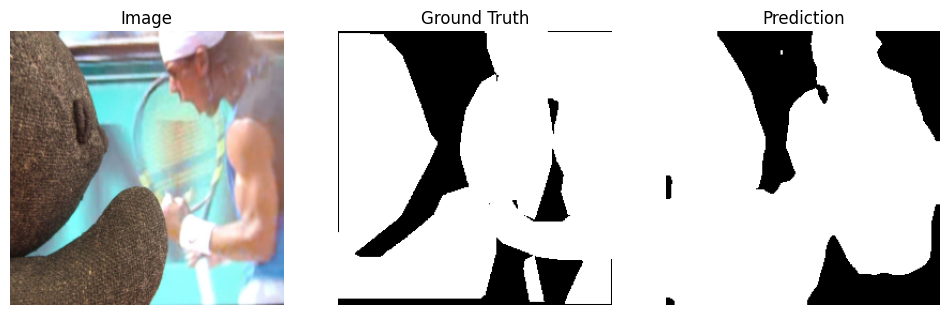

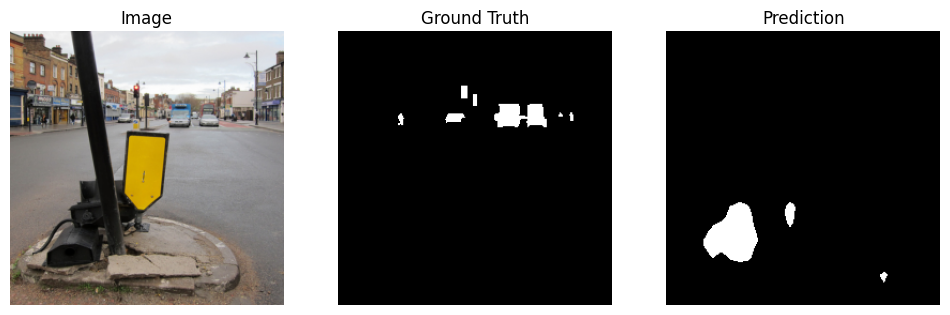

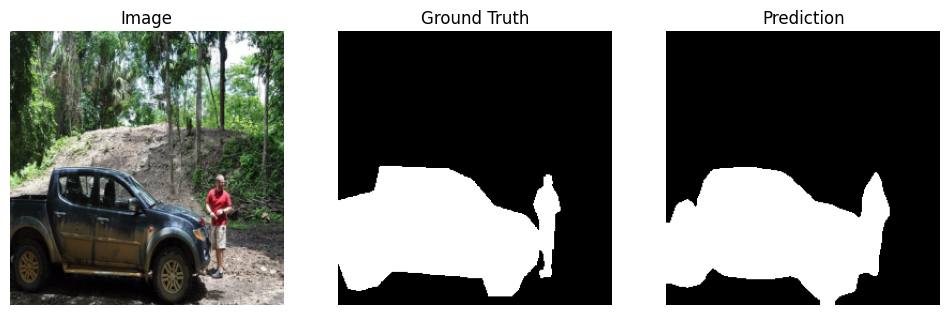

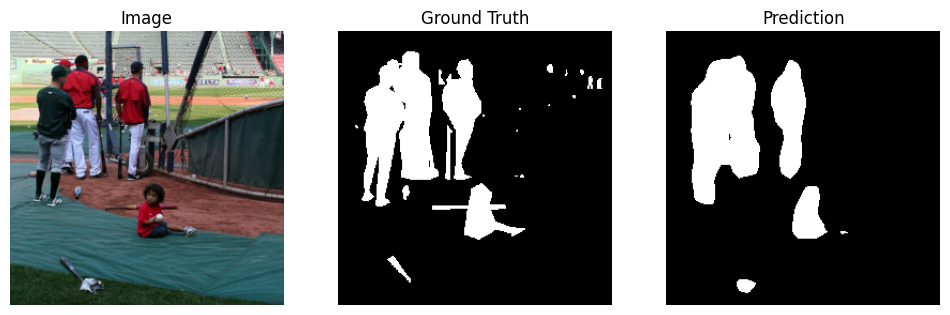

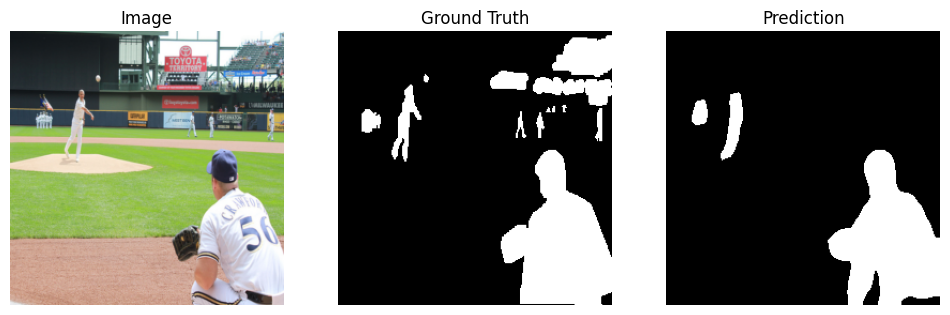

In [8]:
import torch
import matplotlib.pyplot as plt
import torchvision.models.segmentation as models

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = models.deeplabv3_resnet50(pretrained=False, num_classes=1, aux_loss=False)
model.to(device)

checkpoint_path = "deeplabv3_binary_final.pth"
state_dict = torch.load(checkpoint_path, map_location=device)

state_dict = {k: v for k, v in state_dict.items() if "aux_classifier" not in k}
model.load_state_dict(state_dict, strict=False)

def evaluate_and_visualize(model, val_loader, device, num_samples=3):
    model.eval()
    samples = 0
    with torch.no_grad():
        for images, masks in val_loader:
            images, masks = images.to(device), masks.to(device)
            outputs = model(images)["out"]
            preds = torch.sigmoid(outputs) > 0.5
            for i in range(images.size(0)):
                if samples >= num_samples:
                    return
                img = images[i].cpu().permute(1, 2, 0).numpy()
                gt = masks[i].cpu().squeeze().numpy()
                pred = preds[i].cpu().squeeze().numpy()
                fig, axs = plt.subplots(1, 3, figsize=(12, 4))
                axs[0].imshow(img)
                axs[0].set_title("Image")
                axs[1].imshow(gt, cmap="gray")
                axs[1].set_title("Ground Truth")
                axs[2].imshow(pred, cmap="gray")
                axs[2].set_title("Prediction")
                for ax in axs:
                    ax.axis("off")
                plt.show()
                samples += 1

evaluate_and_visualize(model, val_loader, device, num_samples=5)

Using device: cuda


/tmp/ipython-input-1416288604.py:98: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()


Resuming training from epoch 26


Epoch 26/30 [Training]:   0%|          | 0/667 [00:00<?, ?it/s]/tmp/ipython-input-1416288604.py:123: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
/tmp/ipython-input-1416288604.py:137: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Epoch [26/30] - Train Loss: 0.3057, Val Loss: 0.2762
Best model updated!
Backbone unfrozen, fine-tuning full model!


...

Epoch [28/30] - Train Loss: 0.2836, Val Loss: 0.2925


Epoch [29/30] - Train Loss: 0.2516, Val Loss: 0.2749
Best model updated!


Epoch [30/30] - Train Loss: 0.2303, Val Loss: 0.2884
Additional 5 epochs completed!


/tmp/ipython-input-1416288604.py:190: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Mean IoU: 0.6521527048886708
Mean Dice: 0.7894581450721478
Pixel Accuracy: 0.8771074414253235


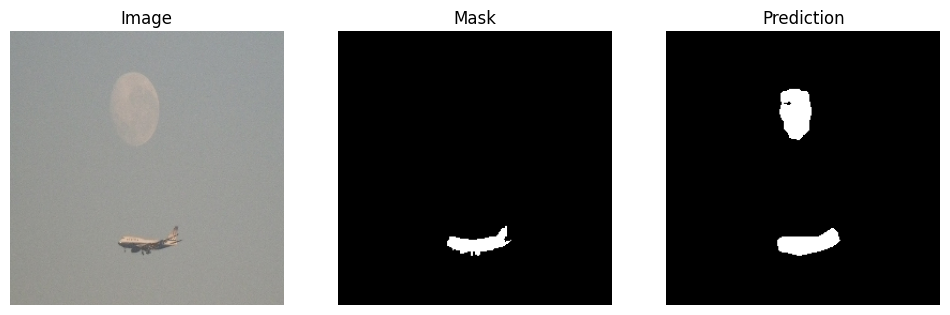

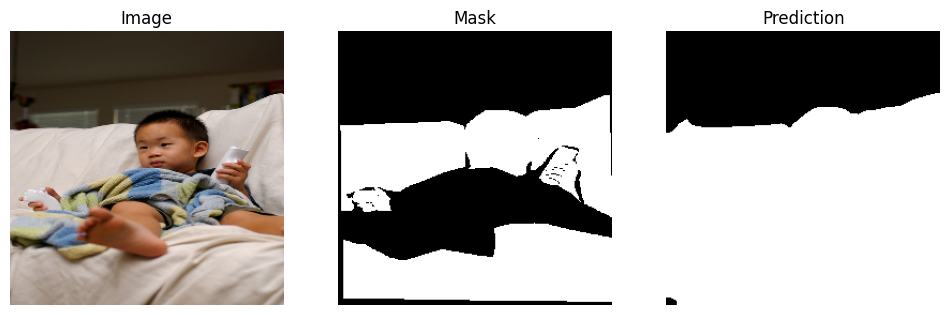

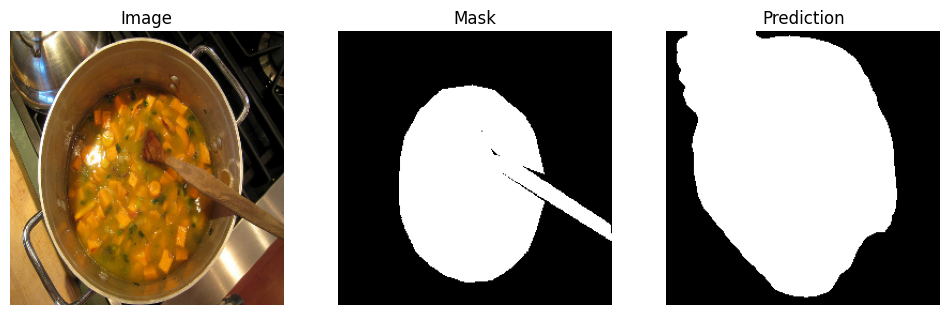

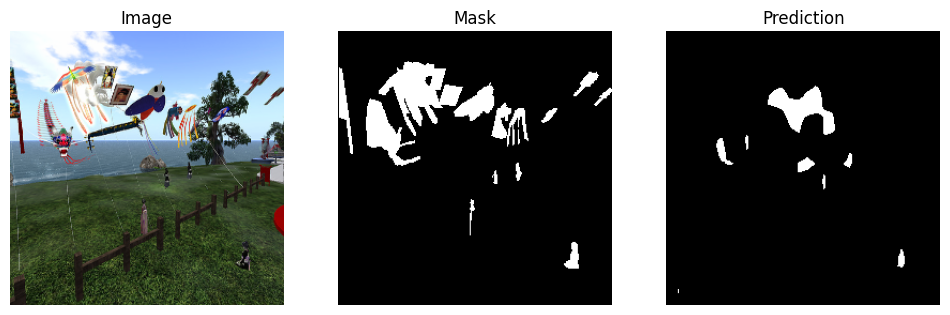

In [11]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import numpy as np
import albumentations as A
from albumentations.pytorch import ToTensorV2
from torchvision.models.segmentation import deeplabv3_resnet50, DeepLabV3_ResNet50_Weights
from skimage.draw import polygon
from tqdm import tqdm
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

num_epochs = 5
start_epoch = 26
batch_size = 6
learning_rate = 1e-4
weight_decay = 1e-5
image_size = 256
num_classes = 1 # Changed from 2 to 1 to match checkpoint
checkpoint_path = "deeplabv3_binary_final.pth"

class CocoMaskedDataset(Dataset):
    def __init__(self, images_path, annotations_path, transform=None):
        self.images_path = images_path
        self.transform = transform
        import json
        with open(annotations_path, "r") as f:
            coco = json.load(f)
        self.images = {img["id"]: img["file_name"] for img in coco["images"]}
        self.annotations = {}
        for ann in coco["annotations"]:
            img_id = ann["image_id"]
            if img_id not in self.annotations:
                self.annotations[img_id] = []
            self.annotations[img_id].append(ann)

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_id = list(self.images.keys())[idx]
        img_path = os.path.join(self.images_path, self.images[img_id])
        img = np.array(Image.open(img_path).convert("RGB"))
        # Create binary mask (0 for background, 1 for object)
        mask = np.zeros(img.shape[:2], dtype=np.uint8)
        anns = self.annotations.get(img_id, [])
        for ann in anns:
            for seg in ann["segmentation"]:
                if isinstance(seg, list) and len(seg) % 2 == 0:
                    poly = np.array(seg).reshape(-1, 2)
                    # Ensure polygon coordinates are within image bounds
                    rr, cc = polygon(poly[:, 1], poly[:, 0], shape=img.shape[:2])
                    mask[rr, cc] = 1
        if self.transform:
            augmented = self.transform(image=img, mask=mask)
            img = augmented["image"]
            mask = augmented["mask"]
        # Ensure mask is float and has a channel dimension for BCEWithLogitsLoss
        return img, mask.float().unsqueeze(0) # Added unsqueeze(0)

train_transform = A.Compose([
    A.Resize(image_size, image_size),
    A.HorizontalFlip(p=0.5),
    A.ColorJitter(p=0.3),
    A.Normalize(mean=(0.485,0.456,0.406), std=(0.229,0.224,0.225)),
    ToTensorV2()
])
val_transform = A.Compose([
    A.Resize(image_size, image_size),
    A.Normalize(mean=(0.485,0.485,0.485), std=(0.229,0.229,0.229)), # Corrected normalization for validation
    ToTensorV2()
])

annotations_path= "/content/drive/MyDrive/VISION_AI/annotations/instances_val2017.json"
images_path = "/content/drive/MyDrive/VISION_AI/val2017"

dataset = CocoMaskedDataset(images_path, annotations_path, transform=train_transform)
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
train_dataset, val_dataset = torch.utils.data.random_split(dataset, [train_size, val_size])
val_dataset.dataset.transform = val_transform # Apply validation transform to validation split

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=0)

weights = DeepLabV3_ResNet50_Weights.DEFAULT
model = deeplabv3_resnet50(weights=weights, aux_loss=True) # Changed aux_loss to True
model.classifier[4] = nn.Conv2d(256, num_classes, kernel_size=1) # binary segmentation
model.to(device)

criterion = nn.BCEWithLogitsLoss() # Changed to BCEWithLogitsLoss for binary segmentation
optimizer = optim.Adam(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
scaler = torch.cuda.amp.GradScaler()

def freeze_backbone(model, freeze=True):
    for param in model.backbone.parameters():
        param.requires_grad = not freeze

freeze_backbone(model, freeze=True)

# Load checkpoint
checkpoint = torch.load(checkpoint_path, map_location=device)
# Remove aux_classifier keys if they exist in the checkpoint
checkpoint = {k: v for k, v in checkpoint.items() if "aux_classifier" not in k}
model.load_state_dict(checkpoint, strict=False) # Set strict=False to ignore missing aux_classifier keys
print(f"Resuming training from epoch {start_epoch}")

# Training function
def train_resume(model, train_loader, val_loader, criterion, optimizer, num_epochs, device, start_epoch, checkpoint_interval=5):
    best_val_loss = float("inf")
    backbone_unfrozen = False # Track if backbone has been unfrozen
    for epoch in range(start_epoch, start_epoch + num_epochs):
        model.train()
        train_loss = 0.0
        for images, masks in tqdm(train_loader, desc=f"Epoch {epoch}/{start_epoch+num_epochs-1} [Training]", leave=False):
            images, masks = images.to(device), masks.to(device)
            optimizer.zero_grad()
            with torch.cuda.amp.autocast():
                outputs = model(images)["out"]
                loss = criterion(outputs, masks)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
            train_loss += loss.item() * images.size(0)
        avg_train_loss = train_loss / len(train_loader.dataset)

        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for images, masks in val_loader:
                images, masks = images.to(device), masks.to(device)
                with torch.cuda.amp.autocast():
                    outputs = model(images)["out"]
                    loss = criterion(outputs, masks)
                val_loss += loss.item() * images.size(0)
        avg_val_loss = val_loss / len(val_loader.dataset)

        print(f"Epoch [{epoch}/{start_epoch+num_epochs-1}] - Train Loss: {avg_train_loss:.4f}, Val Loss: {avg_val_loss:.4f}")

        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            torch.save(model.state_dict(), f"deeplabv3_resumed_best.pth")
            print("Best model updated!")

        # Unfreeze backbone after the first resumed epoch (which is start_epoch)
        if epoch == start_epoch and not backbone_unfrozen:
             freeze_backbone(model, freeze=False)
             backbone_unfrozen = True
             print("Backbone unfrozen, fine-tuning full model!")


        if (epoch - start_epoch + 1) % checkpoint_interval == 0:
            torch.save(model.state_dict(), f"deeplabv3_resumed_epoch{epoch}.pth")
    return model

# Run resumed training
trained_model = train_resume(model, train_loader, val_loader, criterion, optimizer, num_epochs, device, start_epoch=start_epoch) # Pass start_epoch
torch.save(trained_model.state_dict(), "deeplabv3_resumed_final_5more.pth")
print("Additional 5 epochs completed!")

# --- Evaluation Metrics & Prediction Visualization ---
def iou_score(preds, masks): # Removed num_classes as it's binary now
    preds = torch.sigmoid(preds) > 0.5 # Apply sigmoid and threshold for binary
    intersection = ((preds == 1) & (masks == 1)).sum().item()
    union = ((preds == 1) | (masks == 1)).sum().item()
    return intersection / (union + 1e-6)

def dice_score(preds, masks): # Removed num_classes as it's binary now
    preds = torch.sigmoid(preds) > 0.5 # Apply sigmoid and threshold for binary
    intersection = ((preds == 1) & (masks == 1)).sum().item()
    total = (preds == 1).sum().item() + (masks == 1).sum().item()
    return 2*intersection / (total + 1e-6)

def pixel_accuracy(preds, masks):
    preds = torch.sigmoid(preds) > 0.5 # Apply sigmoid and threshold for binary
    return (preds == masks).float().mean().item()

# Evaluate on validation set
trained_model.eval()
all_preds = []
all_masks = []
with torch.no_grad():
    for images, masks in val_loader:
        images, masks = images.to(device), masks.to(device)
        with torch.cuda.amp.autocast():
            outputs = trained_model(images)["out"]
        all_preds.append(outputs)
        all_masks.append(masks)
all_preds = torch.cat(all_preds)
all_masks = torch.cat(all_masks)

print("Mean IoU:", iou_score(all_preds, all_masks))
print("Mean Dice:", dice_score(all_preds, all_masks))
print("Pixel Accuracy:", pixel_accuracy(all_preds, all_masks))

# Visualize a few predictions
images, masks = next(iter(val_loader))
images, masks = images.to(device), masks.to(device)
with torch.no_grad():
    preds = trained_model(images)["out"]
preds = (torch.sigmoid(preds) > 0.5).float().cpu().squeeze(1).numpy() # Apply sigmoid, threshold, and remove channel dim
images = images.cpu().permute(0,2,3,1).numpy()
masks = masks.cpu().squeeze(1).numpy() # Remove channel dim from masks

for i in range(min(4, len(images))):
    plt.figure(figsize=(12,4))
    plt.subplot(1,3,1)
    plt.title("Image")
    # Denormalize image for visualization
    mean = np.array([0.485, 0.485, 0.485])
    std = np.array([0.229, 0.229, 0.229])
    img = images[i] * std + mean
    img = np.clip(img, 0, 1)
    plt.imshow(img)
    plt.axis('off')
    plt.subplot(1,3,2)
    plt.title("Mask")
    plt.imshow(masks[i], cmap="gray")
    plt.axis('off')
    plt.subplot(1,3,3)
    plt.title("Prediction")
    plt.imshow(preds[i], cmap="gray")
    plt.axis('off')
    plt.show()